/var/folders/5x/tsnb6cyx1yv0tybv8lb6493c0000gn/T/ipykernel_5329/149243169.py:34: RuntimeWarning: Mean of empty slice.
  ec2_mean = ec2_val.mean(axis=0)
/Users/belhajali/Documents/GitHub/Cloud-based-SLR-1/venv310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/belhajali/Documents/GitHub/Cloud-based-SLR-1/venv310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/belhajali/Documents/GitHub/Cloud-based-SLR-1/venv310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/belhajali/Documents/GitHub/Cloud-based-SLR-1/venv310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret

ValueError: x and y must have same first dimension, but have shapes (70,) and (1,)

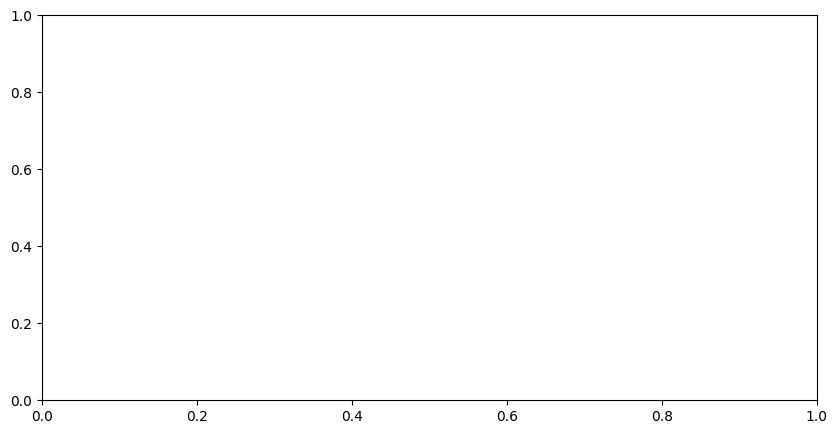

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json, glob, os

# ── Load EC2 epoch logs ──────────────────────────────────────────────
ec2_dir = "../outputs/training"   # adjust path if needed
ec2_files = sorted(glob.glob(os.path.join(ec2_dir, "epoch_logs_*.json")))

ec2_val = []
for f in ec2_files:
    with open(f) as fh:
        data = json.load(fh)
    ec2_val.append([ep["val_accuracy"] for ep in data])

ec2_val = np.array(ec2_val)   # shape (10, 70)

# ── Load SageMaker epoch logs ────────────────────────────────────────
# Paste your 10 runs' val_accuracy lists here (extracted from the log text)
sm_val = np.array([
    [0.010,0.018,0.038,0.056,0.050,0.136,0.242,0.272,0.308,0.332,0.458,0.446,0.476,0.528,0.570,0.602,0.514,0.644,0.652,0.658,0.636,0.686,0.618,0.718,0.678,0.678,0.718,0.744,0.714,0.736,0.746,0.714,0.722,0.732,0.762,0.760,0.748,0.762,0.764,0.788,0.742,0.780,0.774,0.800,0.794,0.794,0.808,0.688,0.738,0.792,0.772,0.812,0.790,0.774,0.796,0.812,0.830,0.834,0.824,0.810,0.808,0.816,0.730,0.758,0.778,0.808,0.810,0.832,0.816,0.794],
    [0.010,0.024,0.038,0.046,0.048,0.072,0.140,0.194,0.272,0.330,0.342,0.312,0.382,0.424,0.458,0.522,0.548,0.576,0.604,0.580,0.668,0.656,0.692,0.696,0.692,0.718,0.730,0.700,0.746,0.754,0.756,0.766,0.742,0.746,0.744,0.774,0.764,0.792,0.778,0.762,0.776,0.778,0.796,0.814,0.798,0.804,0.774,0.792,0.782,0.806,0.750,0.788,0.760,0.792,0.828,0.800,0.832,0.834,0.822,0.828,0.728,0.772,0.826,0.782,0.808,0.792,0.804,0.812,0.814,0.810],
    [0.010,0.026,0.046,0.068,0.066,0.100,0.138,0.202,0.230,0.232,0.260,0.316,0.338,0.382,0.424,0.478,0.498,0.526,0.560,0.556,0.582,0.646,0.626,0.588,0.638,0.668,0.678,0.692,0.690,0.690,0.692,0.674,0.686,0.752,0.710,0.722,0.776,0.742,0.770,0.772,0.758,0.734,0.782,0.760,0.774,0.760,0.774,0.744,0.780,0.774,0.772,0.792,0.768,0.686,0.714,0.756,0.808,0.786,0.794,0.810,0.790,0.782,0.682,0.758,0.760,0.766,0.776,0.750,0.784,0.786],
    [0.010,0.008,0.026,0.044,0.044,0.114,0.132,0.214,0.206,0.272,0.364,0.360,0.472,0.476,0.530,0.520,0.528,0.552,0.586,0.562,0.590,0.644,0.604,0.654,0.718,0.640,0.712,0.706,0.728,0.746,0.712,0.760,0.760,0.738,0.774,0.778,0.778,0.800,0.774,0.768,0.800,0.762,0.798,0.776,0.806,0.812,0.818,0.824,0.802,0.810,0.802,0.812,0.828,0.802,0.828,0.776,0.764,0.804,0.802,0.806,0.798,0.802,0.788,0.810,0.820,0.812,0.830,0.802,0.802,0.812],
    [0.012,0.014,0.050,0.030,0.048,0.140,0.212,0.268,0.284,0.382,0.422,0.460,0.502,0.528,0.588,0.584,0.568,0.628,0.648,0.618,0.660,0.672,0.632,0.738,0.716,0.688,0.666,0.764,0.716,0.754,0.720,0.774,0.732,0.722,0.742,0.772,0.788,0.810,0.784,0.772,0.768,0.772,0.764,0.772,0.650,0.724,0.752,0.774,0.806,0.816,0.812,0.758,0.732,0.800,0.786,0.830,0.842,0.830,0.806,0.802,0.774,0.750,0.754,0.786,0.830,0.782,0.822,0.794,0.804,0.804],
    [0.012,0.024,0.052,0.050,0.070,0.064,0.120,0.180,0.252,0.300,0.258,0.312,0.364,0.410,0.448,0.462,0.496,0.470,0.580,0.608,0.598,0.650,0.644,0.666,0.678,0.680,0.654,0.718,0.696,0.770,0.696,0.708,0.698,0.738,0.722,0.746,0.772,0.742,0.758,0.682,0.732,0.758,0.780,0.796,0.820,0.808,0.796,0.778,0.792,0.784,0.778,0.792,0.716,0.740,0.776,0.772,0.808,0.828,0.852,0.754,0.800,0.762,0.782,0.830,0.770,0.800,0.784,0.792,0.814,0.756],
    [0.008,0.016,0.034,0.038,0.070,0.100,0.142,0.240,0.298,0.398,0.418,0.386,0.554,0.580,0.570,0.668,0.664,0.706,0.704,0.732,0.698,0.724,0.768,0.728,0.774,0.774,0.746,0.796,0.794,0.828,0.808,0.806,0.816,0.758,0.792,0.816,0.826,0.800,0.806,0.832,0.850,0.820,0.838,0.838,0.846,0.862,0.834,0.868,0.860,0.850,0.854,0.816,0.784,0.814,0.832,0.862,0.794,0.814,0.822,0.862,0.862,0.838,0.826,0.816,0.840,0.816,0.842,0.856,0.862,0.850],
    [0.008,0.012,0.044,0.036,0.040,0.086,0.122,0.186,0.234,0.256,0.254,0.384,0.458,0.498,0.552,0.548,0.588,0.576,0.584,0.640,0.630,0.648,0.710,0.694,0.690,0.722,0.712,0.756,0.724,0.756,0.784,0.768,0.758,0.770,0.738,0.788,0.764,0.776,0.768,0.762,0.752,0.780,0.796,0.802,0.800,0.806,0.790,0.738,0.786,0.792,0.800,0.800,0.790,0.830,0.812,0.824,0.836,0.852,0.858,0.780,0.810,0.854,0.808,0.802,0.826,0.812,0.818,0.830,0.826,0.848],
    [0.014,0.012,0.042,0.050,0.050,0.060,0.118,0.214,0.280,0.178,0.354,0.434,0.490,0.482,0.512,0.560,0.586,0.592,0.622,0.642,0.650,0.706,0.736,0.750,0.742,0.756,0.742,0.736,0.736,0.754,0.752,0.776,0.758,0.758,0.782,0.790,0.798,0.794,0.798,0.826,0.848,0.814,0.828,0.802,0.820,0.816,0.838,0.836,0.810,0.812,0.814,0.810,0.845,0.827,0.833,0.823,0.827,0.781,0.846,0.838,0.836,0.834,0.836,0.840,0.820,0.836,0.834,0.836,0.824,0.818],
    [0.010,0.016,0.040,0.046,0.044,0.082,0.132,0.208,0.246,0.224,0.336,0.418,0.472,0.494,0.536,0.554,0.582,0.594,0.616,0.646,0.642,0.688,0.724,0.732,0.738,0.748,0.744,0.754,0.742,0.766,0.762,0.778,0.770,0.784,0.780,0.792,0.796,0.788,0.804,0.822,0.836,0.818,0.824,0.830,0.842,0.826,0.838,0.844,0.818,0.820,0.828,0.822,0.851,0.824,0.760,0.794,0.814,0.808,0.848,0.842,0.838,0.846,0.838,0.844,0.826,0.838,0.840,0.844,0.830,0.824],
])  # shape (10, 70)
print("ec2_val shape:", ec2_val.shape)
print("sm_val shape:", sm_val.shape)

epochs = np.arange(1, 71)

ec2_mean = ec2_val.mean(axis=0)
ec2_std  = ec2_val.std(axis=0)
sm_mean  = sm_val.mean(axis=0)
sm_std   = sm_val.std(axis=0)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, ec2_mean, color="#1f77b4", linewidth=1.8, label="EC2 (mean)")
ax.fill_between(epochs, ec2_mean - ec2_std, ec2_mean + ec2_std,
                color="#1f77b4", alpha=0.15, label="EC2 ±1 std")

ax.plot(epochs, sm_mean, color="#d62728", linewidth=1.8, label="SageMaker (mean)")
ax.fill_between(epochs, sm_mean - sm_std, sm_mean + sm_std,
                color="#d62728", alpha=0.15, label="SageMaker ±1 std")

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Validation accuracy", fontsize=11)
ax.set_xlim(1, 70)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.savefig("../outputs/training/convergence.png", dpi=150, bbox_inches="tight")
plt.show()